# Reconocimiento de Patrones
[Curso de Reconocimiento de Patrones](https://https://domingomery.ing.puc.cl/teaching/patrones/)

Departamento de Ciencia de la Computación

Universidad Catolica de Chile

(c) Domingo Mery, http://domingomery.ing.uc.cl



# EJERCICIO PR.E02: PROCESAMIENTO DE IMÁGENES

El objetivo de este ejercicio es aprender las funciones básicas de procesamiento de imágenes.

Con este fin se cuenta con una imagen que debe ser procesada de diversas maneras (cambio de tamaño, rotación, equalización y filtrado).

<font color='red'>OJO: Para realizar este ejercicio **PUEDES** re-utilizar los código disponibles en el [GitHub del curso](https://github.com/domingomery/patrones?tab=readme-ov-file#clase-04-ju-19-mar-2026) o bien usar el código que quieras que encuentres googleando, o bien usando alguna IA. Es imprescindible que sepas usar estas funciones como preprocesamiento de una imagen antes de hacer una clasificación y que entiendas cómo está implementada la función que estás usando. </font>

<font color='green'>Si usas IA, es importante que sepas bien lo que la IA está haciendo, de ninguna manera copia y pega lo que te dice la IA sin entender nada porque no vas a aprender, y vas a desaprovechar la gran oportunidad que te ha dado la vida de estar en la universidad en un curso presencial con un profesor que te puede explicar lo que no entiendas.</font>

<font color='blue'>**DEBES** colocar la fuente de dónde has obtenido la función que estás utilizando. Si usas IA debes poner el prompt. Si usas una función que encontraste en Internet debes poner la URL. Si usas un código del curso debes decir cuál es. Si es invención tuya, debes decir que es creación propia. Sé honesto contigo mismo, la vida te lo va a agradecer, y el profesor también.</font>


#IMPORTANTE: Cambiar el nombre del archivo

<font color='red'>ATENCIÓN: ANTES DE SEGUIR, CAMBIA EL NOMBRE DEL ARCHIVO ipynb INCLUYENDO TU RUT</font>

Ejemplo, si este ejercicio es el E02 tu RUT es 12.345.678-9, el nombre de este archivo debe cambiarse a "E02_12345678-9.ipynb". Para hacer esto debes hacer click arriba a la izquierda donde está el nombre del archivo y editarlo.


# IDEA CENTRAL DEL EJERCICIO


En este ejercicio se implementarán distintos algoritmos de procesamiento de imágenes.

La imagen a procesar se encuentra aquí:


GitHub del curso > clases > PR02_Extraccion_de_Caracteristicas > datos > littlesister.png

(se debe trabajar sólo con el primer canal, es decir una matriz de 1000 x 1000 pixeles que se llamara 'X')

Los algoritmos de procesamiento de imágenes a implementar son del tipo Yk = algoritmo(X), donde X siempre será la misma imagen de 1000 x 1000 definida arriba, y Yk es la salida al procesamiento k. Para cada procesamiento se debe desplegar la salida Y.

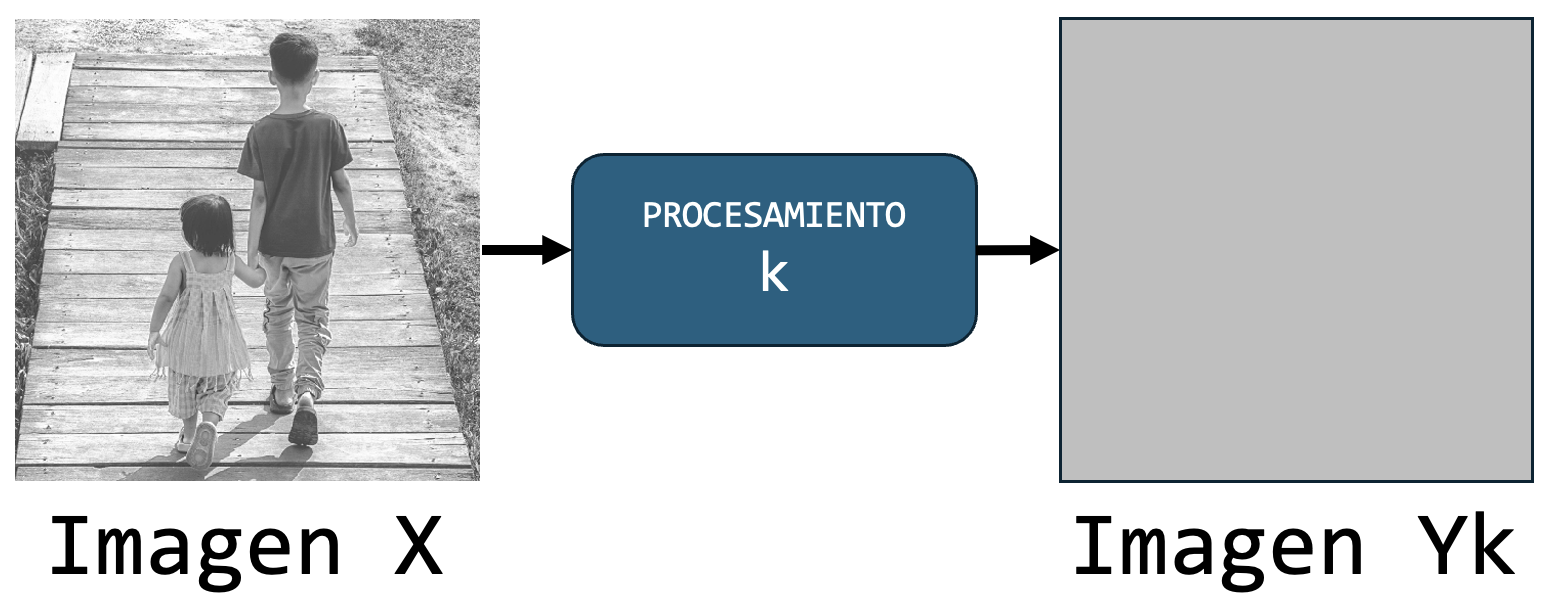


# PREGUNTA 00: LEER Y DESPLEGAR LA IMAGEN X

(1 punto)

0.1 > (1 punto) Leer la imagen mencionada arriba y desplegarla

In [1]:
# For calculation
import numpy as np

# For visualization
from PIL import Image
from scipy import ndimage
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 0.1
REPO = 'https://raw.githubusercontent.com/domingomery/pr/main/clases/'
!wget {REPO}PR02_Extraccion_de_Caracteristicas/datos/littlesister.png

--2026-09-03 03:18:45--  https://raw.githubusercontent.com/domingomery/pr/main/clases/PR02_Extraccion_de_Caracteristicas/datos/littlesister.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 654103 (639K) [image/png]
Saving to: ‘littlesister.png.2’

littlesister.png.2  100%[===================>] 638.77K  --.-KB/s    in 0.05s   

2026-09-03 03:18:45 (13.0 MB/s) - ‘littlesister.png.2’ saved [654103/654103]



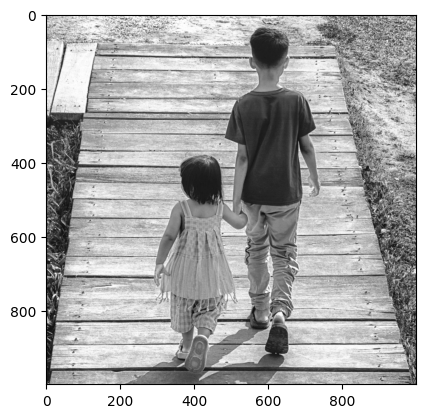

In [3]:
img = Image.open('littlesister.png')
implot = plt.imshow(img,cmap='gray')

# PREGUNTA 01: CAMBIO DE TAMAÑO

(2 puntos)

1.1 > (1 punto) Genera una imagen de 200 x 200 pixeles.


1.2 > (1 punto) Genera una imagen de 1200 x 1200 pixeles.


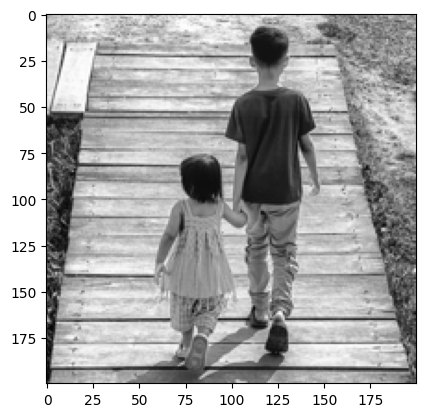

In [4]:
# 1.1
img_resized1 = img.resize((200, 200))
plt.imshow(img_resized1, cmap='gray')


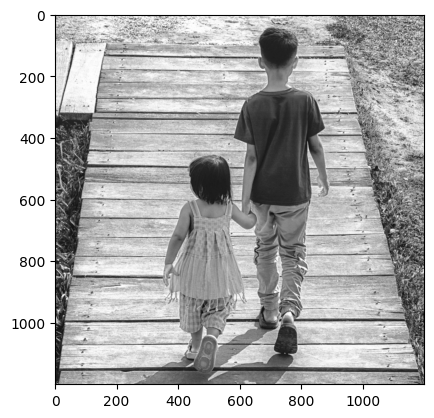

In [5]:
# 1.2
img_resized2 = img.resize((1200, 1200))
plt.imshow(img_resized2, cmap='gray')

# PREGUNTA 02: ROTACIÓN

(3 puntos)

2.1 > (2 puntos) Genera una imagen de 400 x 400 pixeles rotada 45° en sentido horario cuyo centro es el pixel central de la imagen.


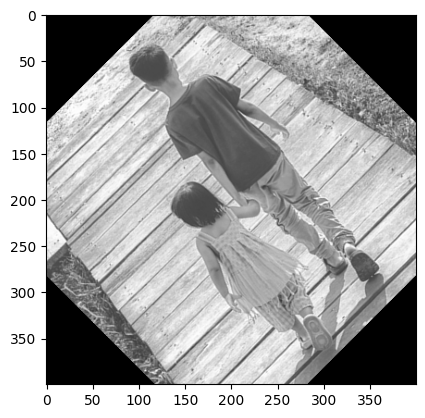

In [6]:
# 2.1
# 1.2
img_resized = img.resize((400, 400))
img_rotated = ndimage.rotate(img_resized, angle=45, reshape=False)
plt.imshow(img_rotated, cmap='gray')

# PREGUNTA 03: EQUALIZACIÓN DE HISTOGRAMA

(6 puntos)

3.1 > (2 puntos) Desplegar el histograma de X.

3.2 > (4 puntos) Equalizar X (mostrar histograma e imagen equalizada).


In [7]:
# De las clases
from  cv2 import imread
from google.colab.patches import cv2_imshow

def howis(img):
  print('size = ',img.shape)
  print('max  = ',np.max(img))
  print('min  = ',np.min(img))


def imhist(X):
  (N,M) = X.shape
  n = 256
  h = np.zeros((256,))
  for i in range(N):
    for j in range(M):
      x = X[i,j]
      h[x] = h[x]+1
  plt.figure(figsize=(60,9))
  plt.bar(range(n),h[0:n])
  plt.show()

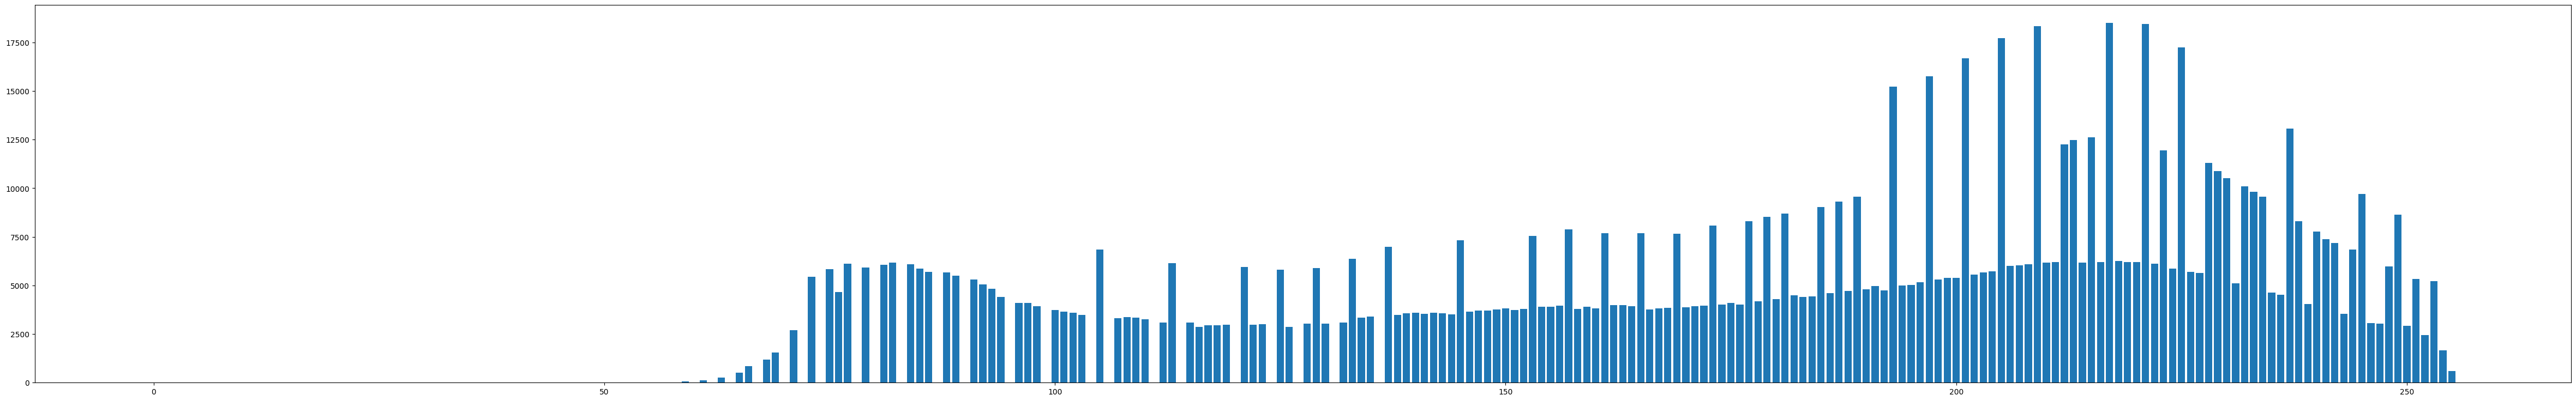

In [8]:
# 3.1
X = imread('littlesister.png', 0)
imhist(X)

In [9]:
# De las clases
def hist_forceuni(img):
    # input: img
    # output: equalized image y

    img_x = img.copy()
    img_x = 255 * ((img_x - img_x.min()) / (img_x.max() - img_x.min()))

    n, m = img_x.shape
    y = np.zeros((n * m, 1), dtype=np.uint8)
    j = np.argsort(img_x.flatten())
    z = np.zeros((n * m, 1), dtype=np.uint8)
    d = int(np.fix((n * m / 256) + 0.5))

    for i in range(255):
        z[i * d:(i + 1) * d] = i * np.ones((d, 1))  # , dtype=np.uint8)
    z[255 * d:n * m] = 255 * np.ones((n * m - 255 * d, 1))  # , dtype=np.uint8)

    y[j] = z
    y = y.reshape(n, m)

    return y

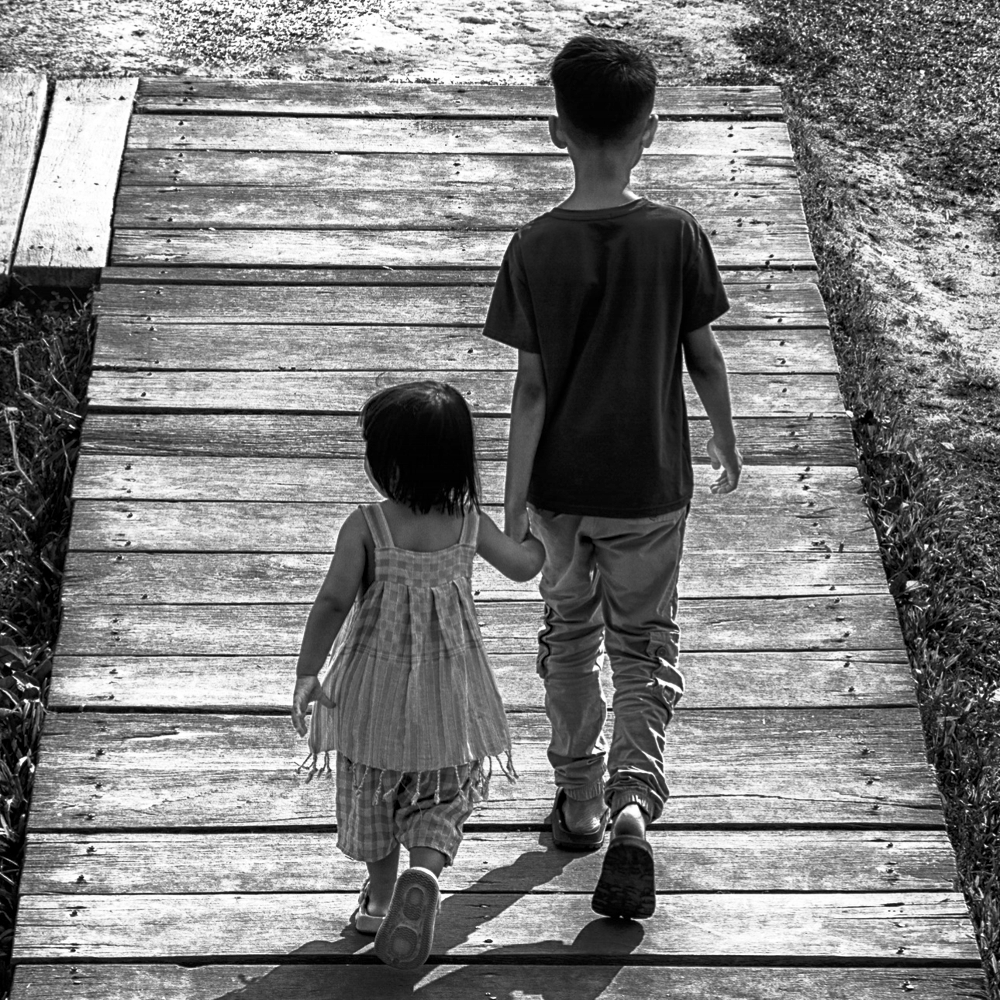

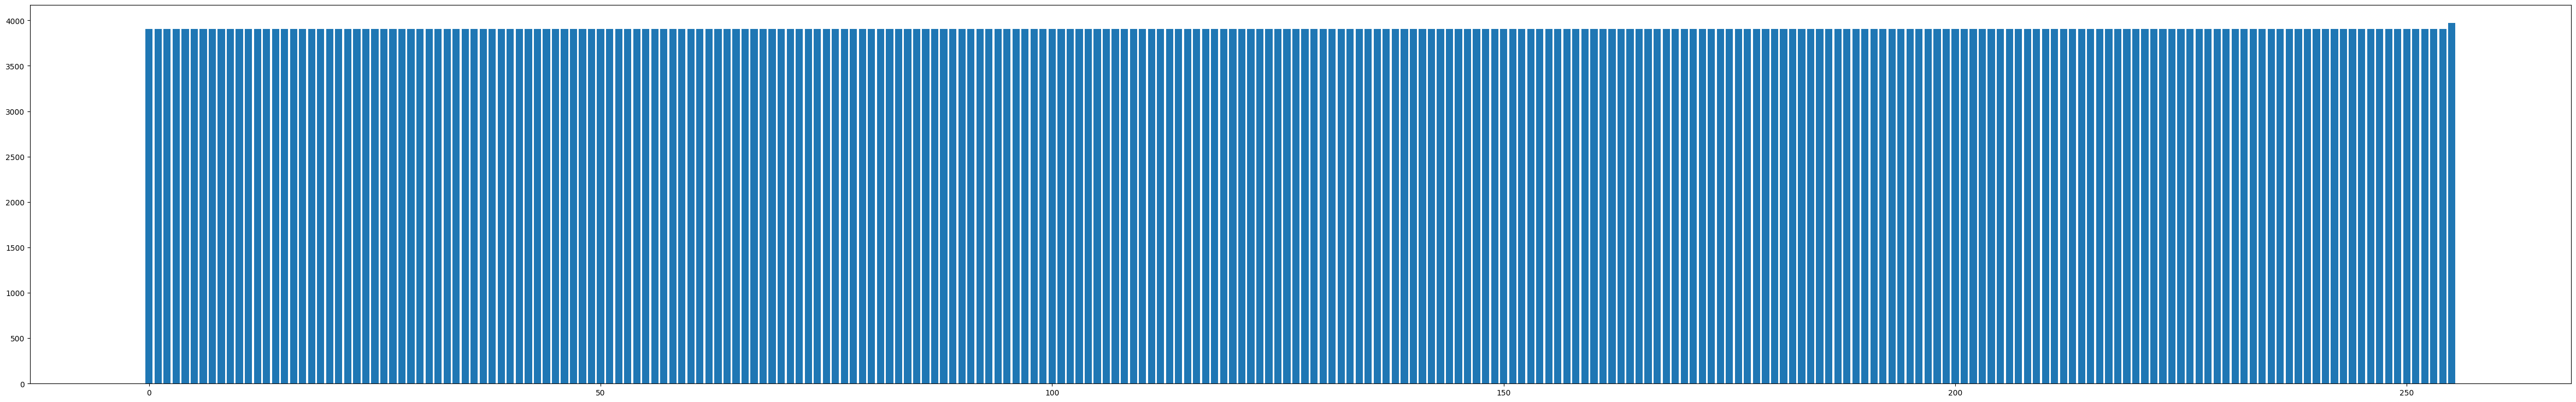

In [10]:
# 3.2
X1 = hist_forceuni(X)
cv2_imshow(X1)
imhist(X1)

# PREGUNTA 04: MÁSCARAS

(5 puntos)

4.1 > (3 puntos) Filtro pasa Bajos: Generar una imagen filtrada por una máscara de m x m elementos, cuyos elementos son iguales a 1/(m*m), con m = 35.

4.2 > (2 puntos) Filtro pasa Altos: Restar de X la imagen obtenida en el paso anterior. <font color='red'>ATENCIÓN: Para visualizar mejor el resultado, despliegue el valor absoluto, y normalícelo entre 0 y 255.</font>



In [19]:
import cv2 as cv
img = cv.imread('littlesister.png',0)

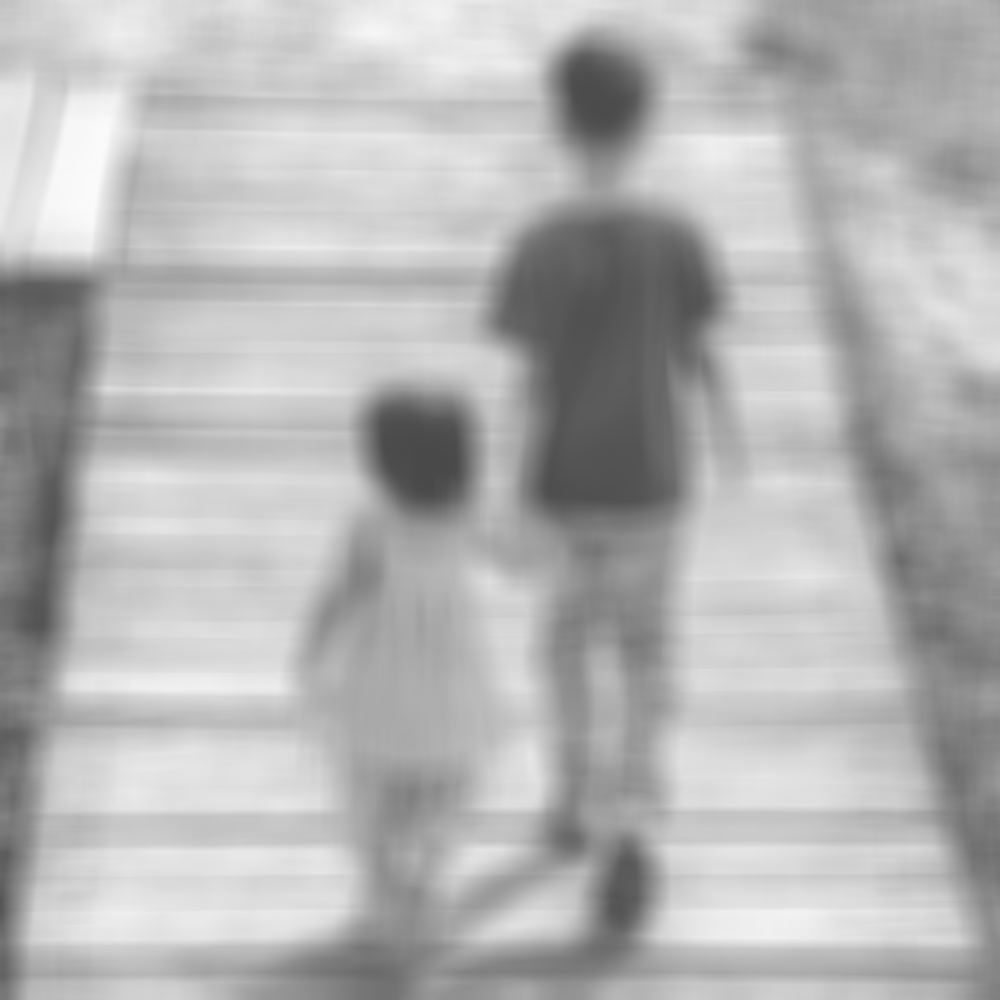

In [24]:
# 4.1 De las clases
m   = 35
Mk  = np.ones((m,m),np.float32)/m/m
L   = cv.filter2D(img,-1,Mk)
cv2_imshow(L)

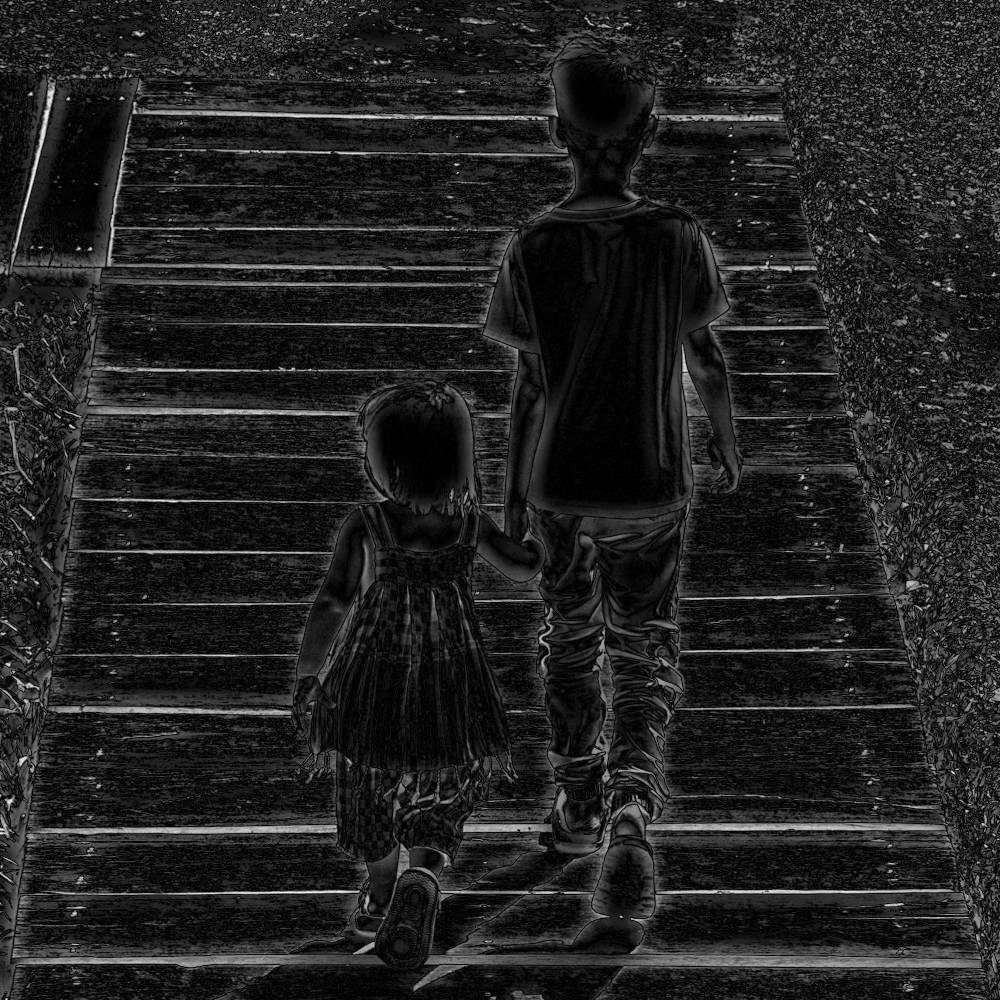

In [25]:
# 4.2
# High Pass Filtering
Id = img.astype(float)
Ld = L.astype(float)
Hd = Id-Ld

# Visualization
H = np.abs(Hd)
H = H-np.min(H)
H = H/np.max(H)*255
H = H.astype(np.uint8)
cv2_imshow(H)


## BONUS

Estudiar este código basado en el [detector de bordes de Canny](https://www.google.com/search?q=how+to+detect+edges+with+canny+opencv+python)

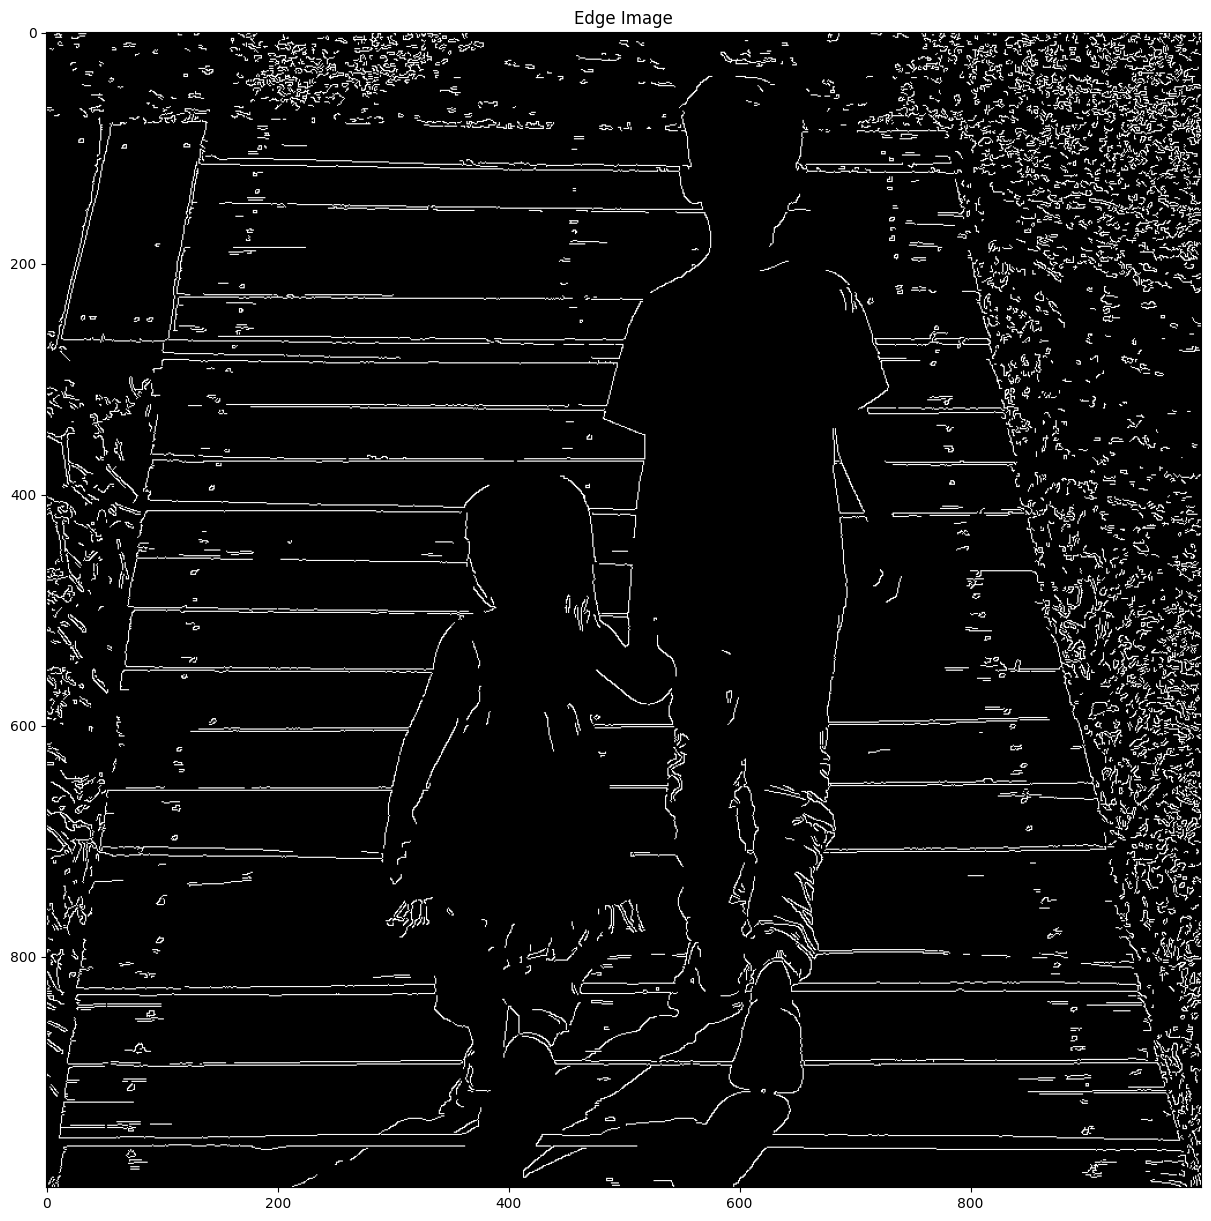

In [30]:
# BONUS
E = cv.Canny(img, 250, 400)
plt.figure(figsize=(15,15))
plt.imshow(E, cmap='gray')
plt.title('Edge Image')
plt.show()
